In [1]:
###################################### imports
from datetime import datetime
import math
import time
import resource
import os
import re
import numpy as np
import pandas as pd
from pyprojroot import here
import matplotlib.pyplot as plt
###################################### constants
DIR_MMSEQS = here() / 'data/mmseqs_clusters/'

###################################### data loading
fps_clust = list(DIR_MMSEQS.rglob('*clusters_id0*'))
list_dfs = []

for fp in fps_clust:
    df = pd.read_csv(fp, sep='\t', header=None, names=['representative', 'member'])
    origin = fp.stem.replace('_clusters_id0', '')
    df['origin'] = origin
    cluster_stats = df.groupby('representative').size().reset_index(name='member_count')
    cluster_stats = cluster_stats.sort_values(
        by=['member_count', 'representative'], 
        ascending=[False, True]
    ).reset_index(drop=True)
    cluster_stats['cluster_rank'] = cluster_stats.index + 1
    df = df.merge(cluster_stats, on='representative')
    df = df.sort_values(by=['cluster_rank', 'member']).reset_index(drop=True)
    df = df[['representative', 'member', 'origin', 'member_count', 'cluster_rank']]
    df[['label', 'percent_id']] = df['origin'].str.split('_', n=1, expand=True)
    list_dfs.append(df)
print(f"{'.'*40}")
print("[MMSeqs2 clustering (all sequences redundant)]\n")

if list_dfs:
    clus_df = pd.concat(list_dfs, ignore_index=True)
    print(clus_df.head(10))
    print(f"{'.'*10}")
    print(clus_df.tail(10))
    print(f"{'.'*40}")
    print(clus_df['origin'].unique())
else:
    print("No cluster files found.")


........................................
[MMSeqs2 clustering (all sequences redundant)]

   representative          member    origin  member_count  cluster_rank  \
0  XP_024214379.1  XP_014282739.1  halys_80            48             1   
1  XP_024214379.1  XP_014282741.1  halys_80            48             1   
2  XP_024214379.1  XP_014282743.1  halys_80            48             1   
3  XP_024214379.1  XP_014282744.1  halys_80            48             1   
4  XP_024214379.1  XP_014282745.1  halys_80            48             1   
5  XP_024214379.1  XP_014282747.1  halys_80            48             1   
6  XP_024214379.1  XP_014282748.1  halys_80            48             1   
7  XP_024214379.1  XP_014282750.1  halys_80            48             1   
8  XP_024214379.1  XP_014282753.1  halys_80            48             1   
9  XP_024214379.1  XP_014282754.1  halys_80            48             1   

   label percent_id  
0  halys         80  
1  halys         80  
2  halys         80

In [2]:
def print_unique_summary(df: pd.DataFrame) -> None:
    """
    Prints the number of unique values and the first 5 unique elements 
    for every column in a pandas DataFrame.
    """
    for col in df.columns:
        unique_vals = df[col].unique()
        num_unique = len(unique_vals)
        first_five = unique_vals[:5].tolist() # tolist() for cleaner console output
        
        print(f"Column: '{col}'")
        print(f"  - Unique count: {num_unique}")
        print(f"  - First 5 unique: {first_five}")
        print("-" * 40)

print_unique_summary(clus_df)

Column: 'representative'
  - Unique count: 104037
  - First 5 unique: ['XP_024214379.1', 'XP_066907129.1', 'XP_066904508.1', 'XP_014285353.1', 'XP_014289481.1']
----------------------------------------
Column: 'member'
  - Unique count: 127974
  - First 5 unique: ['XP_014282739.1', 'XP_014282741.1', 'XP_014282743.1', 'XP_014282744.1', 'XP_014282745.1']
----------------------------------------
Column: 'origin'
  - Unique count: 110
  - First 5 unique: ['halys_80', 'halys_90', 'halys_20', 'halys_40', 'halys_35']
----------------------------------------
Column: 'member_count'
  - Unique count: 300
  - First 5 unique: [48, 38, 35, 23, 19]
----------------------------------------
Column: 'cluster_rank'
  - Unique count: 72957
  - First 5 unique: [1, 2, 3, 4, 5]
----------------------------------------
Column: 'label'
  - Unique count: 10
  - First 5 unique: ['halys', 'union', 'suzukii', 'melanogaster', 'aegypti']
----------------------------------------
Column: 'percent_id'
  - Unique count

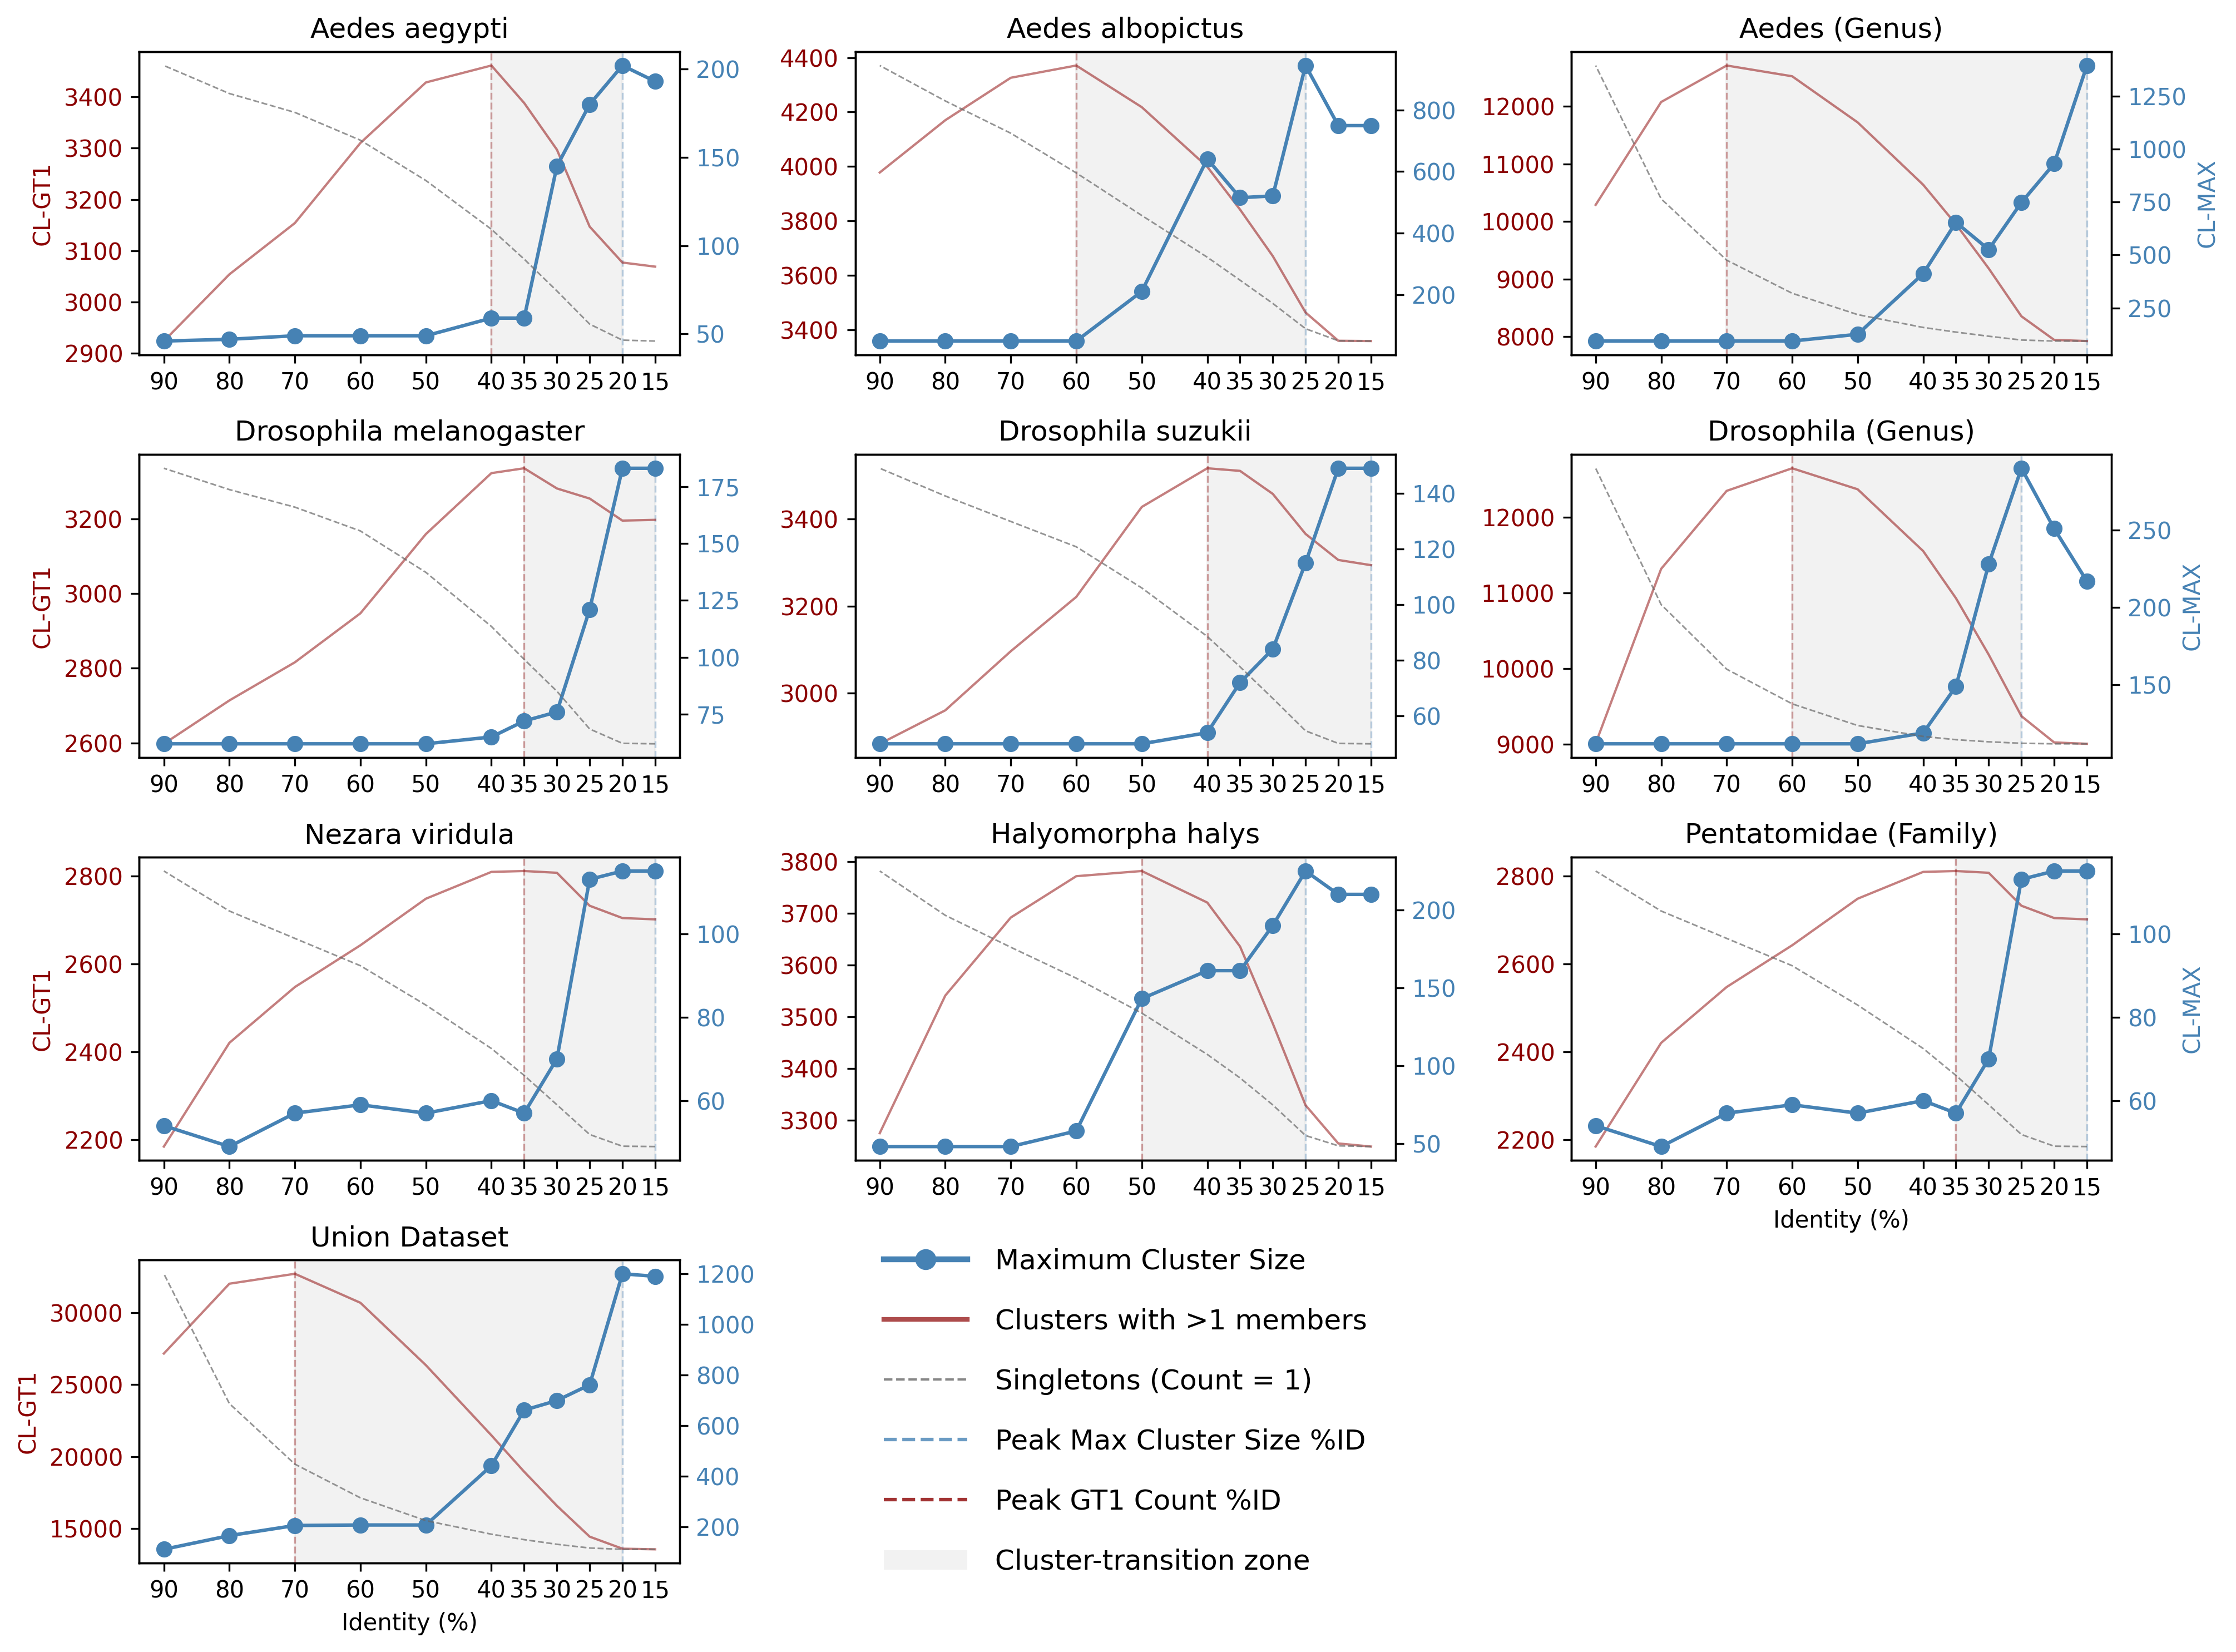

In [22]:
#!/usr/bin/env python3
"""Plot cluster size and count metrics per label with configurable axis titles and peak reference lines."""

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

###################################### PARAMS
SHOW_LINES = True
PLOT_DPI = 300
PLOT_W = 4.5
PLOT_H = 2.5
N_COLS = 3
MAIN_COLOR = 'steelblue'
LINE_COLOR = 'darkred'
SINGLETON_COLOR = 'dimgray'
LIGHT_GRAY = 'lightgray'
SHADE_COLOR = 'gainsboro'

X_LABEL_TEXT = 'Identity (%)'
Y_LEFT_LABEL_TEXT = 'CL-GT1'
Y_RIGHT_LABEL_TEXT = 'CL-MAX'
LEGEND_MAIN_TEXT = 'Maximum Cluster Size'
LEGEND_LINE_TEXT = 'Clusters with >1 members'
LEGEND_SINGLETON_TEXT = 'Singletons (Count = 1)'
LEGEND_PEAK_MAIN_TEXT = 'Peak Max Cluster Size %ID'
LEGEND_PEAK_LINE_TEXT = 'Peak GT1 Count %ID'
LEGEND_SHADE_TEXT = 'Cluster-transition zone'

plt.rcParams['figure.dpi'] = PLOT_DPI

SPECIFIED_ORDER = [
    'aegypti', 'albopictus', 'aedes',
    'melanogaster', 'suzukii', 'drosophila',
    'viridula', 'halys', 'pentatomidae', 'union'
]

# Define custom titles corresponding to your specified order (falls back to label if missing)
CUSTOM_TITLES = {
    'aegypti': 'Aedes aegypti',
    'albopictus': 'Aedes albopictus',
    'aedes': 'Aedes (Genus)',
    'melanogaster': 'Drosophila melanogaster',
    'suzukii': 'Drosophila suzukii',
    'drosophila': 'Drosophila (Genus)',
    'viridula': 'Nezara viridula',
    'halys': 'Halyomorpha halys',
    'pentatomidae': 'Pentatomidae (Family)',
    'union': 'Union Dataset'
}

###################################### EXECUTION
clus_df['percent_id'] = pd.to_numeric(clus_df['percent_id'])
df_u = clus_df[['label', 'percent_id', 'cluster_rank', 'member_count']].drop_duplicates()

df_max = df_u.groupby(['label', 'percent_id'])['member_count'].max().rename('max_size')
df_gt1 = df_u[df_u['member_count'] > 1].groupby(['label', 'percent_id']).size().rename('gt1_count')
df_eq1 = df_u[df_u['member_count'] == 1].groupby(['label', 'percent_id']).size().rename('eq1_count')

df_agg = pd.concat([df_max, df_gt1, df_eq1], axis=1).fillna(0).reset_index()

existing_labels = set(df_agg['label'].unique())
labels = [lbl for lbl in SPECIFIED_ORDER if lbl in existing_labels] + [
    lbl for lbl in df_agg['label'].unique() if lbl not in set(SPECIFIED_ORDER)
]

all_xticks = sorted(df_agg['percent_id'].unique())
total_panels = len(labels) if len(labels) % N_COLS == 0 else len(labels) + 1
n_rows = (total_panels + N_COLS - 1) // N_COLS

fig, axes = plt.subplots(n_rows, N_COLS, figsize=(N_COLS * PLOT_W, n_rows * PLOT_H))
axes = axes.flatten()

for i, lbl in enumerate(labels):
    sub = df_agg[df_agg['label'] == lbl].sort_values('percent_id')
    
    if SHOW_LINES:
        max_size_pid = sub.loc[sub['max_size'].idxmax(), 'percent_id']
        max_gt1_pid = sub.loc[sub['gt1_count'].idxmax(), 'percent_id']
        left_pid, right_pid = min(max_size_pid, max_gt1_pid), max(max_size_pid, max_gt1_pid)
        axes[i].axvspan(left_pid, right_pid, color=SHADE_COLOR, alpha=0.35, zorder=0)
        axes[i].axvline(max_size_pid, color=MAIN_COLOR, linestyle='--', linewidth=0.8, alpha=0.35, zorder=1)
        axes[i].axvline(max_gt1_pid, color=LINE_COLOR, linestyle='--', linewidth=0.8, alpha=0.35, zorder=1)

    # GT1 count (left y-axis)
    axes[i].plot(sub['percent_id'], sub['gt1_count'], color=LINE_COLOR, linewidth=1.0, alpha=0.5, zorder=2)
    
    # Set custom title using the dictionary lookup
    panel_title = CUSTOM_TITLES.get(lbl, lbl)
    axes[i].set_title(panel_title)
    
    axes[i].set_xticks(all_xticks)
    axes[i].tick_params(axis='y', labelcolor=LINE_COLOR)
    axes[i].invert_xaxis()
    
    if i >= total_panels - N_COLS:
        axes[i].set_xlabel(X_LABEL_TEXT)
        
    if i % N_COLS == 0:
        axes[i].set_ylabel(Y_LEFT_LABEL_TEXT, color=LINE_COLOR)

    # Max size (first right twin axis)
    ax2 = axes[i].twinx()
    ax2.plot(sub['percent_id'], sub['max_size'], color=MAIN_COLOR, marker='o', linestyle='-', linewidth=1.5, zorder=3)
    ax2.tick_params(axis='y', labelcolor=MAIN_COLOR)
    
    is_rightmost_col = (i + 1) % N_COLS == 0
    is_last_data_plot = (i == len(labels) - 1) and (len(labels) == total_panels)
    if is_rightmost_col or is_last_data_plot:
        ax2.set_ylabel(Y_RIGHT_LABEL_TEXT, color=MAIN_COLOR)

    # Singletons / eq1 count (second twin axis, independent scale, no y shown)
    ax3 = axes[i].twinx()
    ax3.plot(sub['percent_id'], sub['eq1_count'], color=SINGLETON_COLOR, linestyle='--', linewidth=0.7, alpha=0.7, zorder=2.5)
    ax3.set_yticks([])
    ax3.spines['right'].set_visible(False)

legend_idx = len(labels) if len(labels) < len(axes) else len(labels) - 1
legend_ax = axes[legend_idx]
legend_ax.axis('off')

legend_elements = [
    Line2D([0], [0], color=MAIN_COLOR, marker='o', markersize=8, linewidth=2.5, label=LEGEND_MAIN_TEXT),
    Line2D([0], [0], color=LINE_COLOR, linewidth=2.0, alpha=0.7, label=LEGEND_LINE_TEXT),
    Line2D([0], [0], color=SINGLETON_COLOR, linestyle='--', linewidth=1.0, alpha=0.8, label=LEGEND_SINGLETON_TEXT),
]
if SHOW_LINES:
    legend_elements.extend([
        Line2D([0], [0], color=MAIN_COLOR, linestyle='--', linewidth=1.5, alpha=0.8, label=LEGEND_PEAK_MAIN_TEXT),
        Line2D([0], [0], color=LINE_COLOR, linestyle='--', linewidth=1.5, alpha=0.8, label=LEGEND_PEAK_LINE_TEXT),
        Patch(facecolor=SHADE_COLOR, alpha=0.35, edgecolor='none', label=LEGEND_SHADE_TEXT),
    ])

legend_ax.legend(
    handles=legend_elements, 
    loc='center', 
    frameon=False, 
    fontsize=12, 
    labelspacing=1.2, 
    handlelength=3.0,
    handletextpad=1.0
)

for j in range(legend_idx + 1, len(axes)): 
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()